In [1]:
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
RANDOM_STATE = 42

In [3]:
DATA_PATH = r"C:\Users\aditi\Downloads\archive (2)\spam.csv"

df = pd.read_csv(DATA_PATH, encoding="latin-1", usecols=["v1", "v2"])
df.columns = ["label", "message"]
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (5572, 2)

Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403


In [5]:
# Drop exact duplicate rows and reset the index so it stays contiguous
df.drop_duplicates(inplace=True)
df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5169 entries, 0 to 5168
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5169 non-null   object
 1   message  5169 non-null   object
dtypes: object(2)
memory usage: 80.9+ KB


In [6]:
# Class balance
label_counts = df["label"].value_counts()
print(label_counts)
print((label_counts / len(df) * 100).round(2).astype(str) + " %")

label
ham     4516
spam     653
Name: count, dtype: int64
label
ham     87.37 %
spam    12.63 %
Name: count, dtype: object


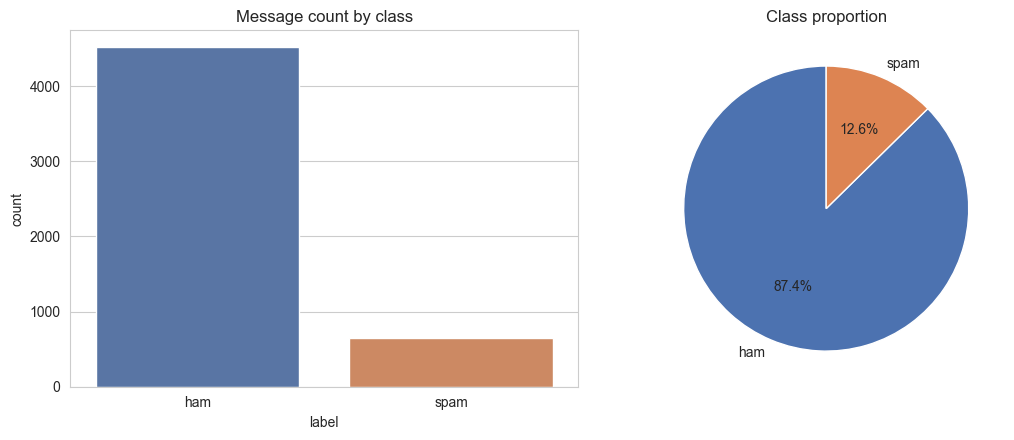

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

sns.barplot(x=label_counts.index, y=label_counts.values,
            hue=label_counts.index, palette=["#4C72B0", "#DD8452"], legend=False, ax=axes[0])
axes[0].set_title("Message count by class")
axes[0].set_ylabel("count")

axes[1].pie(label_counts.values, labels=label_counts.index, autopct="%.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Class proportion")

plt.tight_layout()
plt.show()

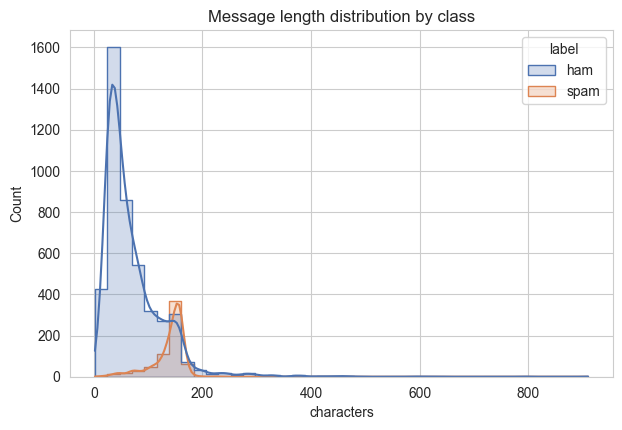

In [8]:
# Message length tends to differ between spam and ham -- a quick engineered feature worth inspecting
df["message_len"] = df["message"].apply(len)

plt.figure(figsize=(7, 4.5))
sns.histplot(data=df, x="message_len", hue="label", bins=40, kde=True,
             palette=["#4C72B0", "#DD8452"], element="step")
plt.title("Message length distribution by class")
plt.xlabel("characters")
plt.show()

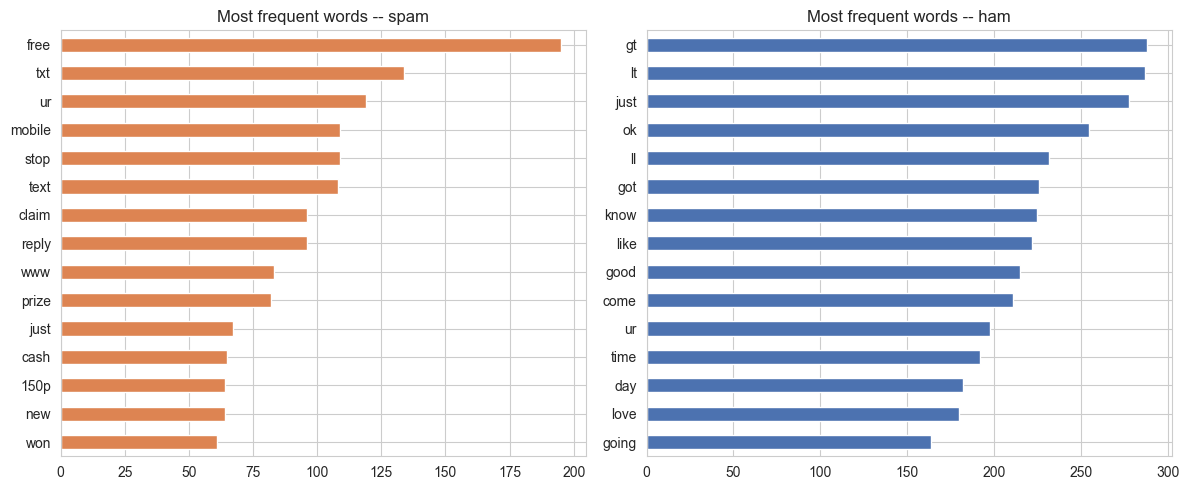

In [9]:
# Most frequent words per class (after removing stopwords) -- cheap alternative to a word cloud,
# no extra dependency required
def top_words(messages, n=15):
    cv = CountVectorizer(stop_words="english", max_features=n)
    bow = cv.fit_transform(messages)
    freqs = bow.sum(axis=0).A1
    return pd.Series(freqs, index=cv.get_feature_names_out()).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
top_words(df.loc[df.label == "spam", "message"]).plot(kind="barh", ax=axes[0], color="#DD8452")
axes[0].set_title("Most frequent words -- spam")
axes[0].invert_yaxis()

top_words(df.loc[df.label == "ham", "message"]).plot(kind="barh", ax=axes[1], color="#4C72B0")
axes[1].set_title("Most frequent words -- ham")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [10]:
def clean_text(text: str) -> str:
    """Lowercase, strip URLs/emails/digits/punctuation, and drop stopwords."""
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"\S+@\S+", " ", text)
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans("", "", string.punctuation))
    tokens = [t for t in text.split() if t not in ENGLISH_STOP_WORDS and len(t) > 1]
    return " ".join(tokens)

df["clean_message"] = df["message"].apply(clean_text)
df[["message", "clean_message"]].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",jurong point crazy available bugis great world...
1,Ok lar... Joking wif u oni...,ok lar joking wif oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts st ...
3,U dun say so early hor... U c already then say...,dun say early hor say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives


In [11]:
encoder = LabelEncoder()
df["label_enc"] = encoder.fit_transform(df["label"])
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

# Index of the "spam" class -- used below so precision/recall/F1 are reported for spam specifically
SPAM = list(encoder.classes_).index("spam")

{'ham': np.int64(0), 'spam': np.int64(1)}


In [12]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["clean_message"], df["label_enc"],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df["label_enc"]
)

vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_df=0.95)
X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (4135, 5097)
Test shape: (1034, 5097)


In [13]:
models = {
    "Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Linear SVM": SVC(kernel="linear"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

fitted_models = {}
rows = []

for name, model in models.items():
    cv_f1 = cross_val_score(model, X_train, y_train, cv=5, scoring="f1").mean()

    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    fitted_models[name] = (model, preds)

    rows.append({
        "Model": name,
        "CV F1 (train)": cv_f1,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, pos_label=SPAM),
        "Recall": recall_score(y_test, preds, pos_label=SPAM),
        "F1": f1_score(y_test, preds, pos_label=SPAM),
    })

results_df = pd.DataFrame(rows).sort_values("F1", ascending=False).reset_index(drop=True)
results_df

,Model,CV F1 (train),Accuracy,Precision,Recall,F1
0,Linear SVM,0.899241,0.984526,0.991453,0.885496,0.935484
1,Random Forest,0.858993,0.970986,0.990291,0.778626,0.871795
2,Naive Bayes,0.849179,0.967118,0.989899,0.748092,0.852174
3,Logistic Regression,0.692488,0.949710,0.987654,0.610687,0.754717


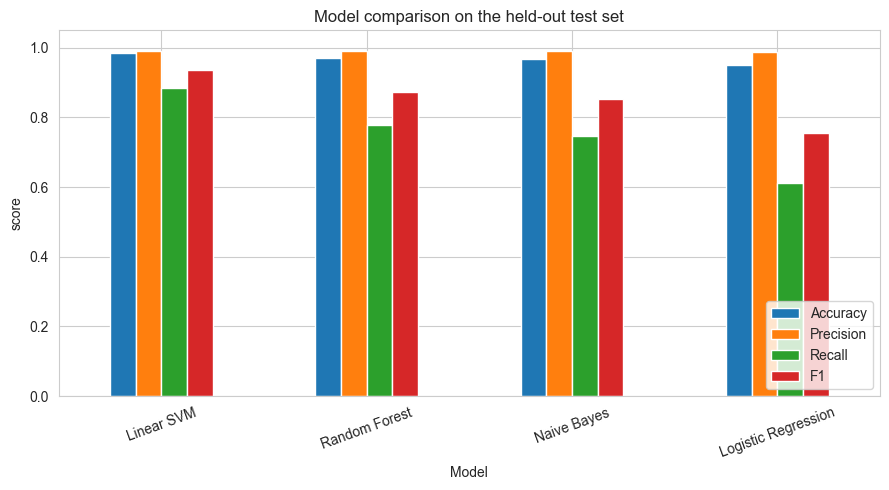

In [14]:
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1"]].plot(
    kind="bar", figsize=(9, 5), ylim=(0, 1.05)
)
plt.title("Model comparison on the held-out test set")
plt.ylabel("score")
plt.xticks(rotation=20)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

Best model by F1: Linear SVM


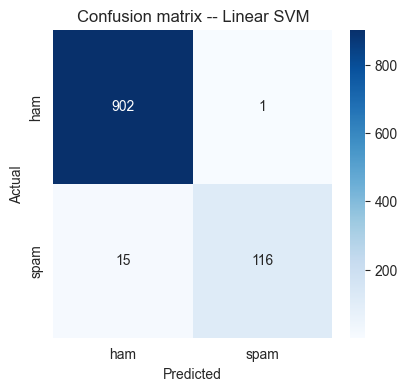

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.99      0.89      0.94       131

    accuracy                           0.98      1034
   macro avg       0.99      0.94      0.96      1034
weighted avg       0.98      0.98      0.98      1034



In [15]:
best_name = results_df.iloc[0]["Model"]
best_model, best_preds = fitted_models[best_name]
print(f"Best model by F1: {best_name}")

cm = confusion_matrix(y_test, best_preds)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.title(f"Confusion matrix -- {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, best_preds, target_names=encoder.classes_))

In [16]:
if best_name == "Naive Bayes":
    param_grid = {"alpha": [0.05, 0.1, 0.3, 0.5, 1.0, 2.0]}
    base_model = MultinomialNB()
elif best_name == "Logistic Regression":
    param_grid = {"C": [0.1, 0.5, 1, 2, 5, 10]}
    base_model = LogisticRegression(max_iter=1000)
elif best_name == "Linear SVM":
    param_grid = {"C": [0.1, 0.5, 1, 2, 5]}
    base_model = SVC(kernel="linear")
else:
    param_grid = {"n_estimators": [100, 200, 400], "max_depth": [None, 20, 40]}
    base_model = RandomForestClassifier(random_state=RANDOM_STATE)

grid_search = GridSearchCV(base_model, param_grid, cv=5, scoring="f1", n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV F1:", round(grid_search.best_score_, 4))

tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)
print("Test F1 after tuning:", round(f1_score(y_test, tuned_preds, pos_label=SPAM), 4))

Best params: {'C': 2}
Best CV F1: 0.9072
Test F1 after tuning: 0.944


In [17]:
joblib.dump(tuned_model, "spam_classifier.joblib")
joblib.dump(vectorizer, "tfidf_vectorizer.joblib")
joblib.dump(encoder, "label_encoder.joblib")
print("Saved: spam_classifier.joblib, tfidf_vectorizer.joblib, label_encoder.joblib")

Saved: spam_classifier.joblib, tfidf_vectorizer.joblib, label_encoder.joblib


In [18]:
def predict_message(text, model=tuned_model, vec=vectorizer, enc=encoder):
    """Return ('spam' | 'ham', spam_probability) for a raw SMS string."""
    cleaned = clean_text(text)
    features = vec.transform([cleaned])
    pred = model.predict(features)[0]
    label = enc.inverse_transform([pred])[0]

    prob = None
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(features)[0][SPAM]
    return label, prob


test_messages = [
    "WINNER!! You have been selected to receive a free cash prize, call now to claim!",
    "Hey, are we still on for lunch tomorrow?",
    "URGENT: Your account has won a guaranteed 1000 pound reward, text CLAIM to 80086",
    "Can you send me the notes from today's class?",
]

for msg in test_messages:
    label, prob = predict_message(msg)
    prob_str = f"{prob:.2%}" if prob is not None else "n/a"
    print(f"[{label.upper():5s} | spam prob: {prob_str}] {msg}")

[SPAM  | spam prob: n/a] WINNER!! You have been selected to receive a free cash prize, call now to claim!
[HAM   | spam prob: n/a] Hey, are we still on for lunch tomorrow?
[SPAM  | spam prob: n/a] URGENT: Your account has won a guaranteed 1000 pound reward, text CLAIM to 80086
[HAM   | spam prob: n/a] Can you send me the notes from today's class?
